# EdgeGAN — Pipeline Centralizado

## Setup

In [ ]:
# ── Dependencias  ───
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
%pip install opencv-python spandrel lpips matplotlib tqdm scikit-image pandas ipywidgets


In [2]:
import os, sys, glob, time
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler
from torch.utils.data import DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from pathlib import Path
from IPython.display import display, clear_output

sys.path.insert(0, '.')

# ── Módulos del proyecto ────
from utils import (
    to_tensor, to_image,
    calcular_psnr, calcular_ssim, calcular_lpips,
    medir_nitidez_bordes, calcular_error_temporal,
)
from model import AnimeEdgeGenerator, PatchDiscriminator, EdgeDiscriminator
from losses import GeneratorLoss, LSGANLoss
from prepare_data import prepare_data
from train import AnimePairDataset, MemmapDataset, save_checkpoint, load_checkpoint
from infer import upscale

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = DEVICE == 'cuda'

# Permite a cuDNN elegir el kernel más rápido para el tamaño de entrada fijo
torch.backends.cudnn.benchmark = USE_AMP

print(f'Device:  {DEVICE}')
print(f'AMP:     {USE_AMP}')
if DEVICE == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device:  cuda
AMP:     True
GPU:     NVIDIA GeForce RTX 3070
VRAM:    8.6 GB


In [3]:
# ── Rutas del proyecto ─────────────────────────────────────────────────────
PATHS = {
    'frames_gt':    'frames',
    'data_train_hr':'data/train/hr',
    'data_train_lr':'data/train/lr',
    'data_val_hr':  'data/val/hr',
    'data_val_lr':  'data/val/lr',
    'models_dir':   'models',
    'checkpoints':  'checkpoints',
    'output_single':'pruebas/out',
    'output_video': 'pruebas/output',
    'video_frames': 'video',
    'clip_frames': 'video_clip',
    'patches_train': 'data/patches/train',
}

for p in PATHS.values():
    os.makedirs(p, exist_ok=True)
print('Rutas OK')

Rutas OK


## 1 · Preparación de Datos

Genera los pares LR/HR desde los frames GT usando `prepare_data.py`.  
Con ~19 000 frames tardará unos 20-40 min. También puedes ejecutarlo desde terminal:
```
python prepare_data.py --input_dir frames --output_dir data
```

In [9]:
prepare_data(
    input_dir=PATHS['frames_gt'],
    output_dir='data',
    scale=2,
    val_split=0.05,
)

  [train] 18312 pares generados → data\train\hr
  [val] 963 pares generados → data\val\hr

Datos listos en: data
  Train: 18312 pares
  Val:   963 pares


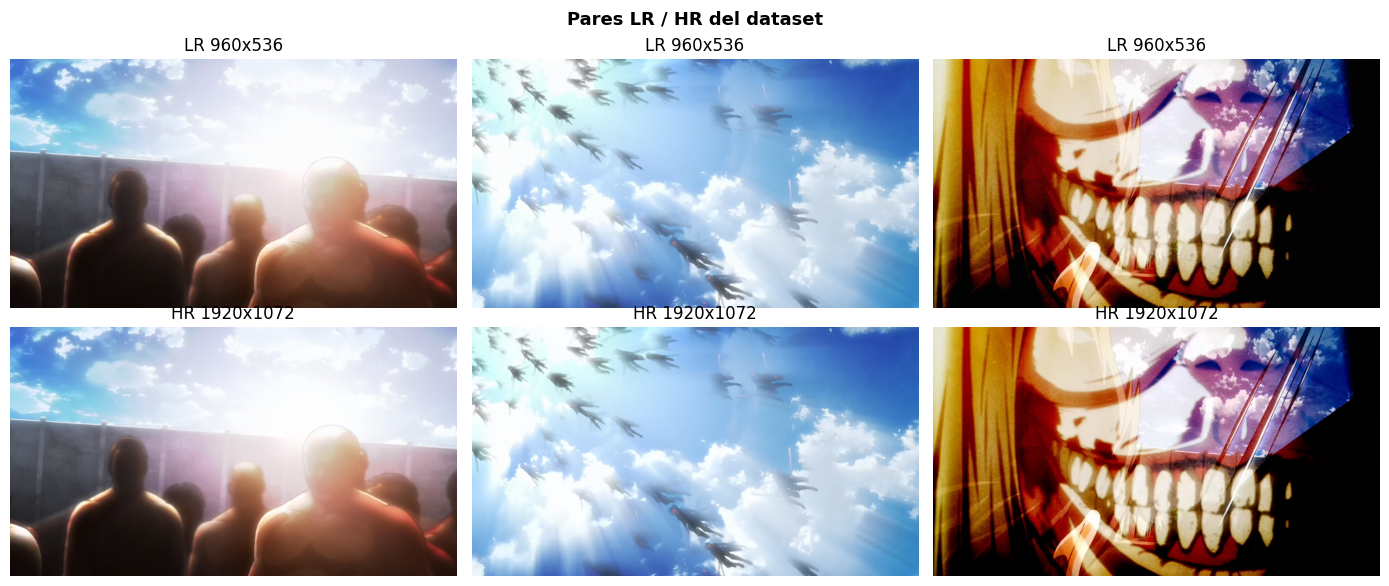

In [3]:
# ── Visualizar un par LR/HR de muestra ────────────────────────────────────
hr_samples = sorted(glob.glob(os.path.join(PATHS['data_train_hr'], '*.png')))[:3]
lr_samples = sorted(glob.glob(os.path.join(PATHS['data_train_lr'], '*.png')))[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Pares LR / HR del dataset', fontsize=13, fontweight='bold')
for i, (lr_p, hr_p) in enumerate(zip(lr_samples, hr_samples)):
    lr_img = cv2.cvtColor(cv2.imread(lr_p), cv2.COLOR_BGR2RGB)
    hr_img = cv2.cvtColor(cv2.imread(hr_p), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(lr_img); axes[0, i].set_title(f'LR {lr_img.shape[1]}x{lr_img.shape[0]}')
    axes[1, i].imshow(hr_img); axes[1, i].set_title(f'HR {hr_img.shape[1]}x{hr_img.shape[0]}')
    for ax in [axes[0, i], axes[1, i]]: ax.axis('off')
plt.tight_layout(); plt.show()

## 3 · Arquitectura AnimeSR-EdgeGAN

Las clases están en `model.py` y las pérdidas en `losses.py`. Aquí solo instanciamos para verificar.

In [4]:
# ── Verificar arquitectura ─────────────────────────────────────────────────
# Parámetros definitivos del modelo (ajusta n_rrdb a 8 para prototipado rápido)
MODEL_CFG = dict(num_features=64, num_rrdb=8, growth=32)

_g = AnimeEdgeGenerator(**MODEL_CFG)
total_params = sum(p.numel() for p in _g.parameters() if p.requires_grad)
print(f'Parámetros del Generador:      {total_params / 1e6:.2f} M')
print(f'PatchDiscriminator:             {sum(p.numel() for p in PatchDiscriminator().parameters()) / 1e6:.2f} M')
print(f'EdgeDiscriminator:              {sum(p.numel() for p in EdgeDiscriminator().parameters()) / 1e6:.2f} M')
del _g

Parámetros del Generador:      5.98 M
PatchDiscriminator:             2.77 M
EdgeDiscriminator:              0.17 M


## 4 · Entrenamiento

In [5]:
# ── Hiperparámetros ────────────────────────────────────────────────────────
CFG = dict(
    patch_size   = 256,
    batch_size   = 12, 
    num_workers  = 0,       # 0 evita IPC
    epochs       = 20, 
    lr_g         = 1e-4,
    lr_d         = 1e-4,
    decay_epoch  = 10,
    save_every   = 1,
    # Pesos de pérdidas
    w_pixel      = 1.0,
    w_perceptual = 0.0,     # VGG desactivado
    w_edge       = 2.0,
    w_freq       = 0.5,
    w_adv        = 0.1,
)
print('Config OK:', CFG)

Config OK: {'patch_size': 256, 'batch_size': 12, 'num_workers': 0, 'epochs': 20, 'lr_g': 0.0001, 'lr_d': 0.0001, 'decay_epoch': 10, 'save_every': 1, 'w_pixel': 1.0, 'w_perceptual': 0.0, 'w_edge': 2.0, 'w_freq': 0.5, 'w_adv': 0.1}


In [6]:
# ── Modelos, optimizadores, pérdidas y scalers AMP ────────────────────
G       = AnimeEdgeGenerator(**MODEL_CFG).to(DEVICE)
D_patch = PatchDiscriminator().to(DEVICE)
D_edge  = EdgeDiscriminator().to(DEVICE)

opt_g = optim.Adam(G.parameters(), lr=CFG['lr_g'], betas=(0.9, 0.999))
opt_d = optim.Adam(
    list(D_patch.parameters()) + list(D_edge.parameters()),
    lr=CFG['lr_d'], betas=(0.9, 0.999),
)

def lr_lambda(e):
    if e < CFG['decay_epoch']: return 1.0
    return max(0.0, 1.0 - (e - CFG['decay_epoch']) / (CFG['epochs'] - CFG['decay_epoch']))

sched_g = optim.lr_scheduler.LambdaLR(opt_g, lr_lambda)
sched_d = optim.lr_scheduler.LambdaLR(opt_d, lr_lambda)

criterion_g = GeneratorLoss(
    w_pixel=CFG['w_pixel'], w_perceptual=CFG['w_perceptual'],
    w_edge=CFG['w_edge'],   w_frequency=CFG['w_freq'],
    w_adversarial=CFG['w_adv'],
).to(DEVICE)
criterion_d = LSGANLoss()

# Scalers para mixed precision (no-op si USE_AMP=False)
scaler_g = GradScaler(enabled=USE_AMP)
scaler_d = GradScaler(enabled=USE_AMP)

# ── Opcional: compilar modelos (~1-2 min la primera época, PyTorch 2.0+) ──
USE_COMPILE = False   # cambiar a True para activar
if USE_COMPILE and hasattr(torch, 'compile'):
    G       = torch.compile(G,       mode='reduce-overhead')
    D_patch = torch.compile(D_patch, mode='reduce-overhead')
    D_edge  = torch.compile(D_edge,  mode='reduce-overhead')
    print('Modelos compilados con torch.compile')

# ── Reanudar desde checkpoint si existe ─────────────────────────────
START_EPOCH = 0
latest_ckpt = sorted(glob.glob(os.path.join(PATHS['checkpoints'], 'checkpoint_epoch*.pth')))
if latest_ckpt:
    START_EPOCH = load_checkpoint(latest_ckpt[-1], G, D_patch, D_edge, opt_g, opt_d)
    _ckpt = torch.load(latest_ckpt[-1], map_location='cpu')
    if 'scaler_g' in _ckpt:
        scaler_g.load_state_dict(_ckpt['scaler_g'])
        scaler_d.load_state_dict(_ckpt['scaler_d'])
    del _ckpt
    print(f'Checkpoint cargado: época {START_EPOCH}')
else:
    print('Entrenamiento desde cero')

# ── Muestra fija para el dashboard (primer par de validación) ─────────
_vis_files_lr = sorted(glob.glob(os.path.join(PATHS['data_val_lr'], '*.png')))
_vis_files_hr = sorted(glob.glob(os.path.join(PATHS['data_val_hr'], '*.png')))
_vis_lr = cv2.imread(_vis_files_lr[0]) if _vis_files_lr else None
_vis_hr = cv2.imread(_vis_files_hr[0]) if _vis_files_hr else None

def _update_dashboard(epoch, epoch_secs):
    if _vis_lr is None:
        return
    G.eval()
    with torch.no_grad(), torch.autocast(device_type='cuda', enabled=USE_AMP):
        _sr = upscale(G, to_tensor(_vis_lr).to(DEVICE), scale=2)
    sr_img = to_image(_sr)
    G.train()

    clear_output(wait=True)
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.28)

    # ── Curvas de pérdida ──────────────────────────────────────────
    for col, (key, label, color) in enumerate([
        ('g_total', 'G Total',   '#e74c3c'),
        ('g_edge',  'Edge Loss', '#2ecc71'),
        ('d',       'D Total',   '#3498db'),
    ]):
        ax = fig.add_subplot(gs[0, col])
        ax.plot(history[key], color=color, linewidth=1.5)
        last = history[key][-1] if history[key] else float('nan')
        ax.set_title(f'{label}  [{last:.4f}]')
        ax.set_xlabel('Época'); ax.grid(alpha=0.3)

    # ── Comparativa visual LR / SR / GT ───────────────────────────
    for col, (img_bgr, title) in enumerate([
        (_vis_lr, 'LR Input'),
        (sr_img,  f'SR — época {epoch + 1}'),
        (_vis_hr, 'Ground Truth'),
    ]):
        ax = fig.add_subplot(gs[1, col])
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10); ax.axis('off')

    mins, secs = divmod(int(epoch_secs), 60)
    lr_now = opt_g.param_groups[0]['lr']
    g_now  = history['g_total'][-1] if history['g_total'] else float('nan')
    e_now  = history['g_edge'][-1]  if history['g_edge']  else float('nan')
    d_now  = history['d'][-1]       if history['d']       else float('nan')
    plt.suptitle(
        f'AnimeSR-EdgeGAN  ·  Época {epoch+1}/{CFG["epochs"]}  ·  '
        f'{mins}m {secs}s/época  ·  lr={lr_now:.1e}  ·  G={g_now:.3f}  edge={e_now:.3f}  D={d_now:.3f}',
        fontsize=11, fontweight='bold',
    )
    plt.show()
    plt.close(fig)

C:\Users\Vato\AppData\Local\Temp\ipykernel_29536\2182145746.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler(enabled=USE_AMP)
C:\Users\Vato\AppData\Local\Temp\ipykernel_29536\2182145746.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler(enabled=USE_AMP)


  → Checkpoint cargado desde época 20
Checkpoint cargado: época 20


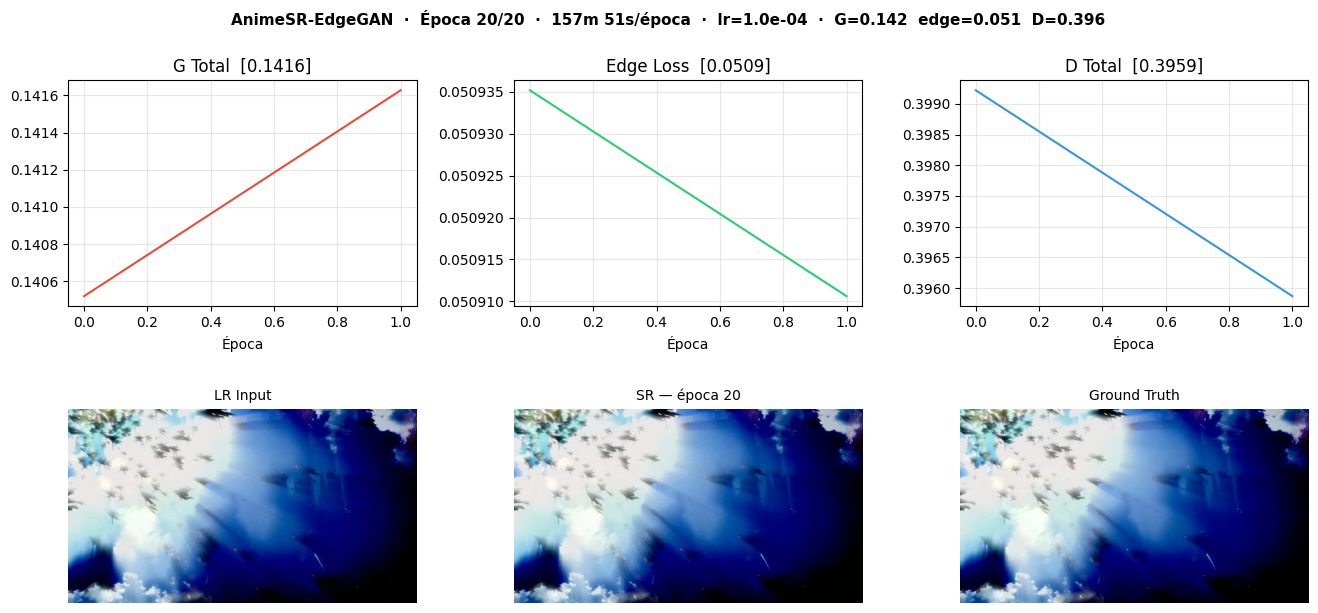

Entrenamiento completado.


In [6]:
# Bucle de entrenamiento con MemmapDataset + AMP
import os as _os
_meta_path = _os.path.join(PATHS['patches_train'], 'meta.npy')
if _os.path.exists(_meta_path):
    # preload=True: carga ~13 GB en RAM al inicio (~20s), luego sin IPC
    train_ds = MemmapDataset(PATHS['patches_train'], preload=True)
    print('Usando MemmapDataset')
else:
    train_ds = AnimePairDataset(PATHS['data_train_hr'], PATHS['data_train_lr'], CFG['patch_size'])
    print('Usando AnimePairDataset (ejecuta prepare_patches.py para acelerar)')

train_dl = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=True,
    drop_last=True,
)
print(f'Dataset: {len(train_ds)} muestras | {len(train_dl)} batches/epoca')

history = {'g_total': [], 'g_edge': [], 'g_pixel': [], 'd': []}

for epoch in range(START_EPOCH, CFG['epochs']):
    G.train(); D_patch.train(); D_edge.train()
    ep = {'g_total': 0., 'g_edge': 0., 'g_pixel': 0., 'd': 0.}
    t0 = time.time()

    pbar = tqdm(train_dl, desc=f'Epoca {epoch+1}/{CFG["epochs"]}', leave=False)
    for lr_b, hr_b in pbar:
        lr_b = lr_b.to(DEVICE, non_blocking=True)
        hr_b = hr_b.to(DEVICE, non_blocking=True)

        # Generador
        opt_g.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', enabled=USE_AMP):
            sr = G(lr_b)
            g_losses = criterion_g(
                sr, hr_b,
                disc_pred_patch=D_patch(sr),
                disc_pred_edge=D_edge(sr),
            )
        scaler_g.scale(g_losses['total']).backward()
        scaler_g.unscale_(opt_g)
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        scaler_g.step(opt_g)
        scaler_g.update()

        # Discriminadores
        sr_d = sr.detach()
        opt_d.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', enabled=USE_AMP):
            l_d = (
                criterion_d(D_patch(hr_b),  True) + criterion_d(D_patch(sr_d), False) +
                criterion_d(D_edge(hr_b),   True) + criterion_d(D_edge(sr_d),  False)
            ) * 0.5
        scaler_d.scale(l_d).backward()
        scaler_d.unscale_(opt_d)
        torch.nn.utils.clip_grad_norm_(
            list(D_patch.parameters()) + list(D_edge.parameters()), 1.0
        )
        scaler_d.step(opt_d)
        scaler_d.update()

        ep['g_total'] += g_losses['total'].item()
        ep['g_edge']  += g_losses['edge'].item()
        ep['g_pixel'] += g_losses['pixel'].item()
        ep['d']       += l_d.item()
        pbar.set_postfix({
            'G':    f"{g_losses['total'].item():.3f}",
            'edge': f"{g_losses['edge'].item():.3f}",
            'D':    f"{l_d.item():.3f}",
        })

    n = len(train_dl)
    for k in ep: history[k].append(ep[k] / n)
    sched_g.step(); sched_d.step()

    if (epoch + 1) % CFG['save_every'] == 0 or epoch == CFG['epochs'] - 1:
        save_checkpoint({
            'epoch':      epoch + 1,
            'generator':  G.state_dict(),
            'disc_patch': D_patch.state_dict(),
            'disc_edge':  D_edge.state_dict(),
            'opt_g':      opt_g.state_dict(),
            'opt_d':      opt_d.state_dict(),
            'scaler_g':   scaler_g.state_dict(),
            'scaler_d':   scaler_d.state_dict(),
        }, os.path.join(PATHS['checkpoints'], f'checkpoint_epoch{epoch+1:04d}.pth'))

    _update_dashboard(epoch, time.time() - t0)

print('Entrenamiento completado.')

In [7]:
import torch

ckpt = torch.load('checkpoints/checkpoint_epoch0020.pth', map_location='cpu')

# Guardar solo el generador
torch.save(ckpt['generator'], 'generator_final.pth')

# Verificar el ahorro
import os
ckpt_size = os.path.getsize('checkpoints/checkpoint_epoch0020.pth') / 1e6
gen_size  = os.path.getsize('generator_final.pth') / 1e6
print(f"Checkpoint completo: {ckpt_size:.1f} MB")
print(f"Solo generador:      {gen_size:.1f} MB")

Checkpoint completo: 107.4 MB
Solo generador:      24.0 MB


## 5 · Evaluación del EdgeGAN

Val: 10 pares
Checkpoints encontrados: 20


Épocas:   0%|          | 0/20 [00:00<?, ?it/s]

  Ép   1 | PSNR=34.28 | Nitidez=88.3
  Ép   2 | PSNR=34.81 | Nitidez=111.3
  Ép   3 | PSNR=35.73 | Nitidez=72.4
  Ép   4 | PSNR=35.56 | Nitidez=89.2
  Ép   5 | PSNR=36.29 | Nitidez=87.9
  Ép   6 | PSNR=35.98 | Nitidez=102.2
  Ép   7 | PSNR=36.23 | Nitidez=83.6
  Ép   8 | PSNR=35.86 | Nitidez=102.3
  Ép   9 | PSNR=36.99 | Nitidez=82.7
  Ép  10 | PSNR=36.61 | Nitidez=78.8
  Ép  11 | PSNR=36.29 | Nitidez=81.5
  Ép  12 | PSNR=35.89 | Nitidez=108.1
  Ép  13 | PSNR=36.30 | Nitidez=92.8
  Ép  14 | PSNR=36.54 | Nitidez=96.1
  Ép  15 | PSNR=36.09 | Nitidez=109.1
  Ép  16 | PSNR=36.36 | Nitidez=122.4
  Ép  17 | PSNR=36.81 | Nitidez=90.2
  Ép  18 | PSNR=37.35 | Nitidez=82.2
  Ép  19 | PSNR=36.91 | Nitidez=82.3
  Ép  20 | PSNR=37.24 | Nitidez=95.5

SSIM + LPIPS para mejor época (18)...


SSIM+LPIPS:   0%|          | 0/10 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


d:\tfm\.venv-1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\tfm\.venv-1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: d:\tfm\.venv-1\Lib\site-packages\lpips\weights\v0.1\vgg.pth
PSNR=37.35 | SSIM=0.9448 | LPIPS=0.2285 | Nitidez=82.2


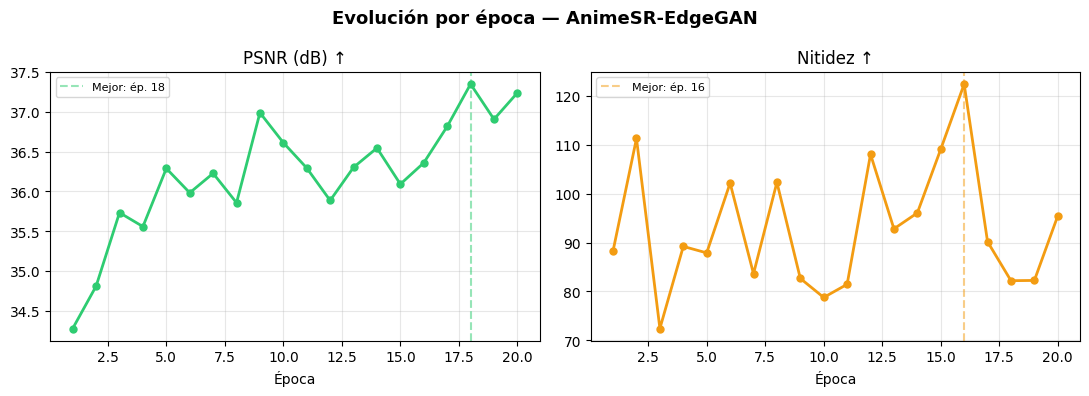

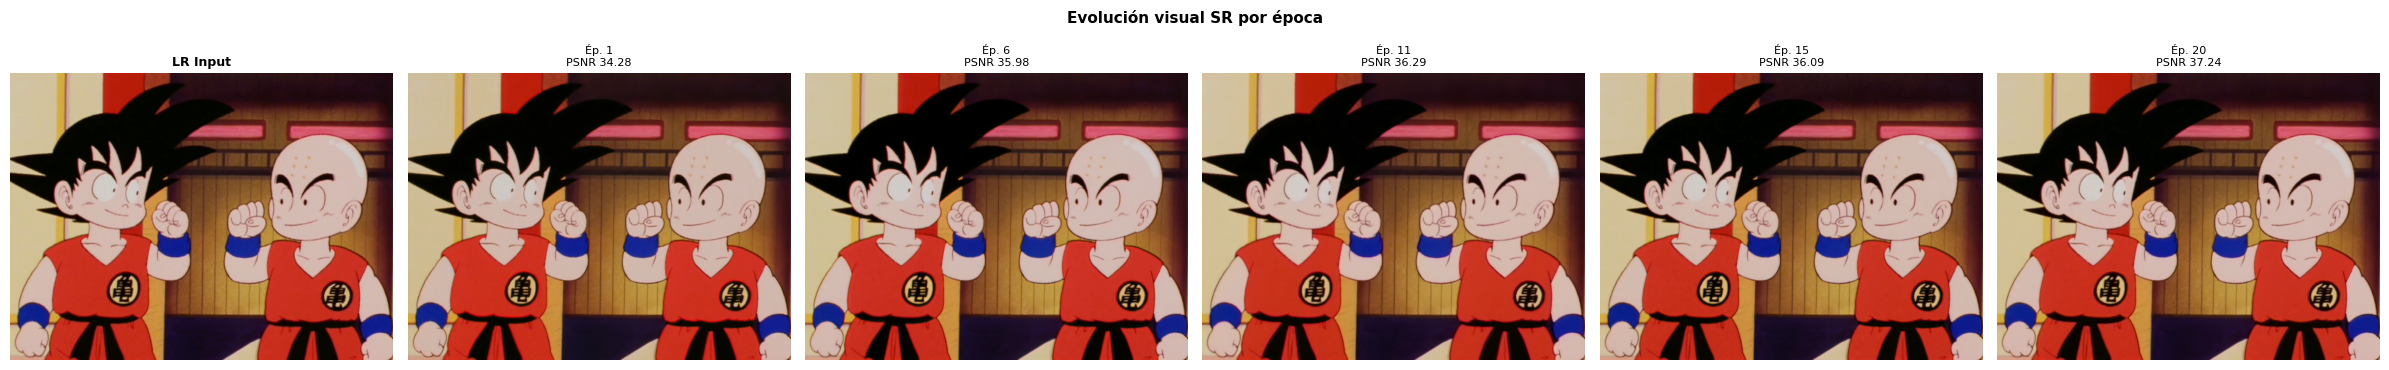


Imágenes guardadas en: pruebas/eval_epochs

── Métricas mejor época (18) ─────────
  PSNR:    37.35 dB
  SSIM:    0.9448
  LPIPS:   0.2285
  Nitidez: 82.20


In [ ]:
# ── Evaluación por épocas — sin GPU Degradation ────────────────────────────
# Bucle por épocas: PSNR y Nitidez (cv2, <1 ms/imagen).
# SSIM y LPIPS solo para la mejor época al final.

VAL_LR_DIR    = PATHS['data_val_lr']
VAL_HR_DIR    = PATHS['data_val_hr']
INFER_INPUT   = r'pruebas/in/frame_dragon.png'
INFER_OUT_DIR = 'pruebas/eval_epochs'
MAX_VAL_SAMPLES = 10

os.makedirs(INFER_OUT_DIR, exist_ok=True)

val_lr_files = sorted(glob.glob(os.path.join(VAL_LR_DIR, '*.png')))
val_hr_files = sorted(glob.glob(os.path.join(VAL_HR_DIR, '*.png')))
if MAX_VAL_SAMPLES and len(val_lr_files) > MAX_VAL_SAMPLES:
    step = len(val_lr_files) // MAX_VAL_SAMPLES
    val_lr_files = val_lr_files[::step][:MAX_VAL_SAMPLES]
    val_hr_files = val_hr_files[::step][:MAX_VAL_SAMPLES]
print(f'Val: {len(val_lr_files)} pares')

infer_img = cv2.imread(INFER_INPUT)
if infer_img is None:
    print(f'No se encontró {INFER_INPUT} — usando primera imagen val LR')
    infer_img = cv2.imread(val_lr_files[0])

ckpt_paths = sorted(glob.glob(os.path.join(PATHS['checkpoints'], 'checkpoint_epoch*.pth')))
if not ckpt_paths:
    raise FileNotFoundError(f'No se encontraron checkpoints en {PATHS["checkpoints"]}/')
print(f'Checkpoints encontrados: {len(ckpt_paths)}')

epoch_metrics = []
epoch_sr_imgs = []

for ckpt_path in tqdm(ckpt_paths, desc='Épocas'):
    ckpt      = torch.load(ckpt_path, map_location='cpu')
    epoch_num = ckpt.get('epoch', int(
        os.path.basename(ckpt_path).replace('checkpoint_epoch', '').replace('.pth', '')
    ))
    G_eval = AnimeEdgeGenerator(**MODEL_CFG).to(DEVICE)
    G_eval.load_state_dict(ckpt['generator'])
    G_eval.eval()
    del ckpt

    # Solo PSNR y Nitidez — ambos cv2, <1 ms por imagen
    psnrs, sharps = [], []
    with torch.no_grad():
        for lr_path, hr_path in zip(val_lr_files, val_hr_files):
            lr_t  = to_tensor(cv2.imread(lr_path)).to(DEVICE)
            hr_np = cv2.imread(hr_path)
            sr_np = to_image(G_eval(lr_t).squeeze(0))
            psnrs.append(calcular_psnr(hr_np, sr_np))
            sharps.append(medir_nitidez_bordes(sr_np))

    m = {'epoch': epoch_num, 'psnr': float(np.mean(psnrs)), 'sharpness': float(np.mean(sharps))}
    epoch_metrics.append(m)

    with torch.no_grad():
        sr_np = to_image(upscale(G_eval, to_tensor(infer_img).to(DEVICE), scale=2).squeeze(0))
    cv2.imwrite(os.path.join(INFER_OUT_DIR, f'epoch_{epoch_num:04d}.png'), sr_np)
    epoch_sr_imgs.append((epoch_num, sr_np))

    del G_eval; torch.cuda.empty_cache()
    tqdm.write(f'  Ép {epoch_num:3d} | PSNR={m["psnr"]:.2f} | Nitidez={m["sharpness"]:.1f}')

# ── SSIM + LPIPS una sola vez en la mejor época ──────────────────────────────
best_idx = int(np.argmax([m['psnr'] for m in epoch_metrics]))
print(f'\nSSIM + LPIPS para mejor época ({epoch_metrics[best_idx]["epoch"]})...')
ckpt_b = torch.load(ckpt_paths[best_idx], map_location='cpu')
G_best = AnimeEdgeGenerator(**MODEL_CFG).to(DEVICE)
G_best.load_state_dict(ckpt_b['generator'])
G_best.eval(); del ckpt_b

ssims, lpips_list = [], []
with torch.no_grad():
    for lr_path, hr_path in tqdm(zip(val_lr_files, val_hr_files),
                                  total=len(val_lr_files), desc='SSIM+LPIPS'):
        lr_t = to_tensor(cv2.imread(lr_path)).to(DEVICE)
        hr_t = to_tensor(cv2.imread(hr_path)).to(DEVICE)
        sr_t = G_best(lr_t)
        ssims.append(calcular_ssim(to_image(hr_t.squeeze(0)), to_image(sr_t.squeeze(0))))
        lpips_list.append(calcular_lpips(hr_t, sr_t, device=DEVICE))
del G_best; torch.cuda.empty_cache()

epoch_metrics[best_idx]['ssim']  = float(np.mean(ssims))
epoch_metrics[best_idx]['lpips'] = float(np.mean(lpips_list))
avg = {k: epoch_metrics[best_idx].get(k, float('nan'))
       for k in ('psnr', 'ssim', 'lpips', 'sharpness')}
print(f'PSNR={avg["psnr"]:.2f} | SSIM={avg["ssim"]:.4f} | LPIPS={avg["lpips"]:.4f} | Nitidez={avg["sharpness"]:.1f}')

# ── Gráfica evolución ────────────────────────────────────────────────────────
epochs_x = [m['epoch'] for m in epoch_metrics]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Evolución por época — EdgeGAN', fontsize=13, fontweight='bold')
for ax, (key, label, color) in zip(axes, [
    ('psnr',      'PSNR (dB) ↑', '#2ecc71'),
    ('sharpness', 'Nitidez ↑',    '#f39c12'),
]):
    vals   = [m[key] for m in epoch_metrics]
    best_i = int(np.argmax(vals))
    ax.plot(epochs_x, vals, color=color, linewidth=2, marker='o', markersize=5)
    ax.axvline(epochs_x[best_i], color=color, linestyle='--', alpha=0.5,
               label=f'Mejor: ép. {epochs_x[best_i]}')
    ax.set_title(label); ax.set_xlabel('Época'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(INFER_OUT_DIR, 'metrics_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Comparativa visual ───────────────────────────────────────────────────────
MAX_VIS = 5
n_ep    = len(epoch_sr_imgs)
selected = (epoch_sr_imgs if n_ep <= MAX_VIS else
            [epoch_sr_imgs[round(i * (n_ep - 1) / (MAX_VIS - 1))] for i in range(MAX_VIS)])

fig2, axs = plt.subplots(1, len(selected) + 1, figsize=(4 * (len(selected) + 1), 4))
axs[0].imshow(cv2.cvtColor(infer_img, cv2.COLOR_BGR2RGB))
axs[0].set_title('LR Input', fontsize=9, fontweight='bold'); axs[0].axis('off')
for ax, (ep_n, sr_np) in zip(axs[1:], selected):
    m_ep = next(m for m in epoch_metrics if m['epoch'] == ep_n)
    ax.imshow(cv2.cvtColor(sr_np, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Ép. {ep_n}\nPSNR {m_ep["psnr"]:.2f}', fontsize=8); ax.axis('off')
plt.suptitle('Evolución visual SR por época', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(INFER_OUT_DIR, 'visual_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImágenes guardadas en: {INFER_OUT_DIR}')
print(f'\n── Métricas mejor época ({epoch_metrics[best_idx]["epoch"]}) ─────────')
print(f'  PSNR:    {avg["psnr"]:.2f} dB')
print(f'  SSIM:    {avg["ssim"]:.4f}')
print(f'  LPIPS:   {avg["lpips"]:.4f}')
print(f'  Nitidez: {avg["sharpness"]:.2f}')


## 6 · Comparativa Final de Modelos

### Evaluación de modelos baseline

In [ ]:
#  Selecciona N_EVAL pares LR/HR del val set de forma estratificada
#  para garantizar cobertura de todo el rango de frames sin sesgo temporal.
import random

N_EVAL   = 5
EVAL_SEED = 42
EVAL_SCALE = 4

# ── Cargar lista completa del val set ────────────────────────────────────
all_lr = sorted(glob.glob(os.path.join(PATHS['data_val_lr'], '*.png')))
all_hr = sorted(glob.glob(os.path.join(PATHS['data_val_hr'], '*.png')))
assert len(all_lr) == len(all_hr), \
    f'Mismatch LR/HR: {len(all_lr)} LR vs {len(all_hr)} HR'
print(f'Val set completo: {len(all_lr)} pares')

# ── Muestreo estratificado por paso fijo ─────────────────────────────────
if len(all_lr) <= N_EVAL:
    eval_lr = all_lr
    eval_hr = all_hr
else:
    step    = len(all_lr) // N_EVAL
    indices = list(range(0, len(all_lr), step))[:N_EVAL]
    eval_lr = [all_lr[i] for i in indices]
    eval_hr = [all_hr[i] for i in indices]

print(f'Subconjunto de evaluación: {len(eval_lr)} pares  '
      f'(paso={len(all_lr)//N_EVAL if len(all_lr)>N_EVAL else 1})')
print(f'Primer frame: {os.path.basename(eval_lr[0])}')
print(f'Último frame: {os.path.basename(eval_lr[-1])}')
print(f'Escala de referencia: {EVAL_SCALE}x')
print()
print('IMPORTANTE: eval_lr / eval_hr son las listas fijas que deben usarse')
print('en TODAS las celdas de comparativa para garantizar igualdad de condiciones.')


Val set completo: 964 pares
Subconjunto de evaluación: 5 pares  (paso=192)
Primer frame: frame10_00003.png
Último frame: frame9_00621.png
Escala de referencia: 4x

IMPORTANTE: eval_lr / eval_hr son las listas fijas que deben usarse
en TODAS las celdas de comparativa para garantizar igualdad de condiciones.


In [10]:
#  Modelos evaluados:
#    - Bicúbico (baseline sin modelo)
#    - Todos los .pth en models/  (vía Spandrel)
#    - AnimeSR-EdgeGAN (generator_final.pth)
#
#  Métricas: PSNR, SSIM, LPIPS, Nitidez (Laplaciana)
#  Salida:   tabla pandas estilizada + CSV en results/
import re
import pandas as pd
from spandrel import ModelLoader

os.makedirs('results', exist_ok=True)


def _detect_scale(path: str, spandrel_model=None) -> int:
    """Detecta escala desde atributo del modelo o nombre de archivo."""
    if spandrel_model is not None and hasattr(spandrel_model, 'scale'):
        return int(spandrel_model.scale)
    name = os.path.basename(path).lower()
    if re.search(r'[_\-\s]4x', name) or name.startswith('4x'):
        return 4
    return 2


def _eval_model_on_subset(model_fn, lr_paths, hr_paths, device, desc='',
                           skip_lpips=False):
    """
    Evalúa model_fn(lr_tensor) -> sr_tensor sobre el subconjunto.
    - skip_lpips=True para el bicúbico (evita cargar VGG innecesariamente).
    - Recorta frames excesivamente grandes antes de inferencia (MAX_LR_DIM)
      para evitar que un frame atípico ralentice toda la evaluación.
    - Libera tensores explícitamente cada frame y vacía caché CUDA cada 10.
    """
    MAX_LR_DIM = 480   # px — lado máximo del LR antes de inferencia

    psnrs, ssims, lpips_vals, sharps = [], [], [], []

    for i, (lr_path, hr_path) in enumerate(tqdm(
            zip(lr_paths, hr_paths), total=len(lr_paths), desc=desc, leave=False)):
        lr_img = cv2.imread(lr_path)
        hr_img = cv2.imread(hr_path)
        if lr_img is None or hr_img is None:
            continue

        # Recortar frames grandes — evita que un frame atípico tarde 10×
        h_lr, w_lr = lr_img.shape[:2]
        if max(h_lr, w_lr) > MAX_LR_DIM:
            scale_down = MAX_LR_DIM / max(h_lr, w_lr)
            new_w = int(w_lr * scale_down)
            new_h = int(h_lr * scale_down)
            lr_img = cv2.resize(lr_img, (new_w, new_h),
                                interpolation=cv2.INTER_AREA)
            hr_img = cv2.resize(hr_img, (new_w * EVAL_SCALE, new_h * EVAL_SCALE),
                                interpolation=cv2.INTER_AREA)
            h_lr, w_lr = new_h, new_w

        # Alinear resolución GT por si hay diferencia de 1px
        hr_img = hr_img[:h_lr * EVAL_SCALE, :w_lr * EVAL_SCALE]

        lr_t = to_tensor(lr_img).to(device)
        with torch.no_grad():
            sr_t = model_fn(lr_t)

        sr_img = to_image(sr_t.float())

        # Alinear resolución SR con GT (spandrel puede dar +1px)
        h_gt, w_gt = hr_img.shape[:2]
        sr_img = sr_img[:h_gt, :w_gt]

        hr_t     = to_tensor(hr_img).to(device)
        sr_t_f32 = to_tensor(sr_img).to(device)

        psnrs.append(calcular_psnr(hr_img, sr_img))
        ssims.append(calcular_ssim(hr_img, sr_img))
        if skip_lpips:
            lpips_vals.append(float('nan'))
        else:
            lpips_vals.append(calcular_lpips(hr_t, sr_t_f32, device=device))
        sharps.append(medir_nitidez_bordes(sr_img))

        # Liberar explícitamente — evita acumulación frame a frame en VRAM
        del lr_t, sr_t, hr_t, sr_t_f32
        if i % 10 == 9:
            torch.cuda.empty_cache()

    torch.cuda.empty_cache()
    return {
        'psnr':      float(np.mean(psnrs))      if psnrs      else float('nan'),
        'ssim':      float(np.mean(ssims))      if ssims      else float('nan'),
        'lpips':     float(np.mean(lpips_vals)) if lpips_vals else float('nan'),
        'sharpness': float(np.mean(sharps))     if sharps     else float('nan'),
    }

# ── Resultado acumulado ───────────────────────────────────────────────────
benchmark_results = {}   # nombre -> {psnr, ssim, lpips, sharpness}
BASELINE_MODELS   = {}   # nombre -> {path, scale}  (para la celda de visualización)


# ── 0. Bicúbico ───────────────────────────────────────────────────────────
print('Evaluando baseline bicúbico...')
def _bicubic_fn(lr_t):
    lr_np = to_image(lr_t.cpu())
    h, w  = lr_np.shape[:2]
    bic   = cv2.resize(lr_np, (w * EVAL_SCALE, h * EVAL_SCALE),
                       interpolation=cv2.INTER_CUBIC)
    return to_tensor(bic).to(DEVICE)

benchmark_results['Bicúbico'] = _eval_model_on_subset(
    _bicubic_fn, eval_lr, eval_hr, DEVICE, desc='Bicúbico'
)
m = benchmark_results['Bicúbico']
print(f'  Bicúbico  PSNR={m["psnr"]:.2f}  SSIM={m["ssim"]:.4f}  '
      f'LPIPS={m["lpips"]:.4f}  Nitidez={m["sharpness"]:.1f}')


# ── 1. Modelos Spandrel (models/*.pth) ────────────────────────────────────
loader      = ModelLoader()
model_files = sorted(glob.glob(os.path.join(PATHS['models_dir'], '*.pth')))
print(f'\nModelos Spandrel encontrados: {len(model_files)}')

for model_path in model_files:
    model_name = os.path.splitext(os.path.basename(model_path))[0]
    print(f'\n── {model_name}')
    try:
        sp_model = loader.load_from_file(model_path).to(DEVICE).eval()
    except Exception as e:
        print(f'  Error al cargar: {e}'); continue

    sp_scale = _detect_scale(model_path, sp_model)
    BASELINE_MODELS[model_name] = {'path': model_path, 'scale': sp_scale}

    _m = sp_model
    _s = sp_scale
    def _sp_fn(lr_t, m=_m, s=_s):
        with torch.no_grad():
            if s == 2 and EVAL_SCALE == 4:
                x2  = m(lr_t)
                out = m(x2)
                del x2          # liberar tensor intermedio
                return out
            elif s == 4 and EVAL_SCALE == 2:
                out  = m(lr_t)
                h, w = lr_t.shape[-2:]
                return out[:, :, :h*2, :w*2]
            else:
                return m(lr_t)

    metrics = _eval_model_on_subset(_sp_fn, eval_lr, eval_hr, DEVICE, desc=model_name)
    benchmark_results[model_name] = metrics
    BASELINE_MODELS[model_name]['metrics'] = metrics

    m = metrics
    print(f'  PSNR={m["psnr"]:.2f}  SSIM={m["ssim"]:.4f}  '
          f'LPIPS={m["lpips"]:.4f}  Nitidez={m["sharpness"]:.1f}')

    del sp_model; torch.cuda.empty_cache()


# ── 2. AnimeSR-EdgeGAN (generator_final.pth) ──────────────────────────────
print('\n── AnimeSR-EdgeGAN (generator_final.pth)')
EDGEGAN_CKPT = 'generator_final.pth'

# Carga robusta: detecta num_rrdb automáticamente
_state    = torch.load(EDGEGAN_CKPT, map_location=DEVICE)
_state    = _state.get('generator', _state) if isinstance(_state, dict) else _state
_indices  = {int(k.split('.')[1]) for k in _state if k.startswith('body.')}
_num_rrdb = (max(_indices) + 1) if _indices else 8

G_eval = AnimeEdgeGenerator(num_features=64, num_rrdb=_num_rrdb, growth=32).to(DEVICE)
G_eval.load_state_dict(_state)
G_eval.eval()
if DEVICE == 'cuda':
    G_eval = G_eval.half()
del _state
print(f'  num_rrdb detectado: {_num_rrdb}  |  FP16: {DEVICE == "cuda"}')

# Warm-up cuDNN para los dos tamaños (LR y x2 intermedio si scale=4)
with torch.no_grad():
    _dum = to_tensor(cv2.imread(eval_lr[0])).to(DEVICE)
    if DEVICE == 'cuda': _dum = _dum.half()
    _x2 = G_eval(_dum)
    if EVAL_SCALE == 4: _x4 = G_eval(_x2)
    del _dum, _x2
    if EVAL_SCALE == 4: del _x4
if DEVICE == 'cuda': torch.cuda.synchronize()
print('  Warm-up completado.')

def _edgegan_fn(lr_t):
    with torch.no_grad():
        if DEVICE == 'cuda': lr_t = lr_t.half()
        return upscale(G_eval, lr_t, scale=EVAL_SCALE).float()

eg_metrics = _eval_model_on_subset(
    _edgegan_fn, eval_lr, eval_hr, DEVICE, desc='AnimeSR-EdgeGAN'
)
benchmark_results['AnimeSR-EdgeGAN'] = eg_metrics
m = eg_metrics
print(f'  PSNR={m["psnr"]:.2f}  SSIM={m["ssim"]:.4f}  '
      f'LPIPS={m["lpips"]:.4f}  Nitidez={m["sharpness"]:.1f}')

del G_eval; torch.cuda.empty_cache()


# ── 3. Tabla resumen ──────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  COMPARATIVA FINAL — {len(eval_lr)} imágenes del val set")
print(f"{'═'*65}")

rows = [{'Modelo': name, **m} for name, m in benchmark_results.items()]
df   = pd.DataFrame(rows).set_index('Modelo')
df.columns = ['PSNR ↑', 'SSIM ↑', 'LPIPS ↓', 'Nitidez ↑']

csv_path = 'results/comparativa_modelos.csv'
df.to_csv(csv_path, float_format='%.4f')
print(f'CSV guardado en: {csv_path}\n')

display(df.style
    .highlight_max(subset=['PSNR ↑', 'SSIM ↑', 'Nitidez ↑'], color='#d5f5e3')
    .highlight_min(subset=['LPIPS ↓'],                         color='#d5f5e3')
    .format('{:.4f}')
    .set_caption(
        f'Comparativa de modelos — {len(eval_lr)} frames val set '
        f'(escala {EVAL_SCALE}x)'))


Evaluando baseline bicúbico...


Bicúbico:   0%|          | 0/5 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


d:\tfm\.venv-1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\tfm\.venv-1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: d:\tfm\.venv-1\Lib\site-packages\lpips\weights\v0.1\vgg.pth
  Bicúbico  PSNR=32.06  SSIM=0.8636  LPIPS=0.2968  Nitidez=10.3

Modelos Spandrel encontrados: 9

── 2x-AnimeSharpV2_RPLKSR_Sharp


...

realesr-animevideov3:   0%|          | 0/5 [00:00<?, ?it/s]

  PSNR=30.43  SSIM=0.8690  LPIPS=0.2870  Nitidez=57.2

── AnimeSR-EdgeGAN (generator_final.pth)
  num_rrdb detectado: 8  |  FP16: True
  Warm-up completado.


AnimeSR-EdgeGAN:   0%|          | 0/5 [00:00<?, ?it/s]

  PSNR=32.41  SSIM=0.8789  LPIPS=0.3041  Nitidez=39.5

═════════════════════════════════════════════════════════════════
  COMPARATIVA FINAL — 5 imágenes del val set
═════════════════════════════════════════════════════════════════
CSV guardado en: results/comparativa_modelos.csv



,PSNR ↑,SSIM ↑,LPIPS ↓,Nitidez ↑
Modelo,,,,
Bicúbico,32.0612,0.8636,0.2968,10.3498
2x-AnimeSharpV2_RPLKSR_Sharp,31.7021,0.8565,0.2826,76.3647
2xHFA2kOmniSR,26.3788,0.7861,0.3323,192.1930
4x_APISR_GRL_GAN_generator,23.1051,0.7730,0.3592,844.1711
4x_IllustrationJaNai_V1_DAT2_190k,30.9607,0.7763,0.3388,408.0109
4x_IllustrationJaNai_V1_ESRGAN_135k,31.6669,0.8081,0.3084,265.7446
4xmssim_drct-s_pretrain,30.8476,0.8635,0.3035,59.0319
RealESRGAN_x4plus_anime_6B,27.0288,0.8236,0.3016,660.9303
realesr-animevideov3,30.4295,0.8690,0.2870,57.2201


In [12]:
#  Inferencia x4 con todos los modelos — pruebas/in → pruebas/out

import re
from spandrel import ModelLoader

INPUT_DIR  = 'pruebas/in'
OUTPUT_DIR = 'pruebas/out'
INFER_SCALE = 4

os.makedirs(OUTPUT_DIR, exist_ok=True)

frames = sorted(
    glob.glob(os.path.join(INPUT_DIR, '*.png')) +
    glob.glob(os.path.join(INPUT_DIR, '*.jpg'))
)
if not frames:
    raise FileNotFoundError(f'No se encontraron imágenes en {INPUT_DIR}')
print(f'Frames encontrados: {len(frames)}')

def _detect_scale(path, sp_model=None):
    if sp_model is not None and hasattr(sp_model, 'scale'):
        return int(sp_model.scale)
    name = os.path.basename(path).lower()
    if re.search(r'[_\-\s]4x', name) or name.startswith('4x'):
        return 4
    return 2

def _run_model(model_fn, lr_img):
    """Inferencia limpia: devuelve BGR uint8, libera tensores."""
    lr_t = to_tensor(lr_img).to(DEVICE)
    with torch.no_grad():
        sr_t = model_fn(lr_t)
    out  = to_image(sr_t.float())
    del lr_t, sr_t
    torch.cuda.empty_cache()
    return out

# ── Construir lista de (nombre_modelo, model_fn) ──────────────────────────
models_to_run = []

# 1. Modelos Spandrel
loader      = ModelLoader()
model_files = sorted(glob.glob(os.path.join(PATHS['models_dir'], '*.pth')))
print(f'Modelos Spandrel: {len(model_files)}')

for model_path in model_files:
    model_name = os.path.splitext(os.path.basename(model_path))[0]
    try:
        sp_model = loader.load_from_file(model_path).to(DEVICE).eval()
    except Exception as e:
        print(f'  Error cargando {model_name}: {e}'); continue

    sp_scale = _detect_scale(model_path, sp_model)
    _m, _s   = sp_model, sp_scale

    def _sp_fn(lr_t, m=_m, s=_s):
        with torch.no_grad():
            if s == 2 and INFER_SCALE == 4:
                x2  = m(lr_t)
                out = m(x2)
                del x2
                return out
            elif s == 4 and INFER_SCALE == 2:
                out  = m(lr_t)
                h, w = lr_t.shape[-2:]
                return out[:, :, :h*2, :w*2]
            else:
                return m(lr_t)

    models_to_run.append((model_name, sp_model, _sp_fn))
    print(f'  Cargado: {model_name}  ({sp_scale}x)')

# 2. AnimeSR-EdgeGAN
print('\nCargando AnimeSR-EdgeGAN...')
_state    = torch.load('generator_final.pth', map_location=DEVICE)
_state    = _state.get('generator', _state) if isinstance(_state, dict) else _state
_indices  = {int(k.split('.')[1]) for k in _state if k.startswith('body.')}
_num_rrdb = (max(_indices) + 1) if _indices else 8

G_infer = AnimeEdgeGenerator(num_features=64, num_rrdb=_num_rrdb, growth=32).to(DEVICE)
G_infer.load_state_dict(_state)
G_infer.eval()
if DEVICE == 'cuda': G_infer = G_infer.half()
del _state
print(f'  num_rrdb={_num_rrdb}  FP16={DEVICE=="cuda"}')

def _edgegan_fn(lr_t):
    with torch.no_grad():
        if DEVICE == 'cuda': lr_t = lr_t.half()
        return upscale(G_infer, lr_t, scale=INFER_SCALE).float()

models_to_run.append(('AnimeSR-EdgeGAN', G_infer, _edgegan_fn))

# ── Warm-up cuDNN con el primer frame ─────────────────────────────────────
print('\nWarm-up cuDNN...')
_dum = to_tensor(cv2.imread(frames[0])).to(DEVICE)
if DEVICE == 'cuda': _dum = _dum.half()
with torch.no_grad():
    _x2 = G_infer(_dum); _x4 = G_infer(_x2)
del _dum, _x2, _x4
if DEVICE == 'cuda': torch.cuda.synchronize()
print('Warm-up completado.\n')

# ── Bucle principal ───────────────────────────────────────────────────────
total = len(models_to_run) * len(frames)
done  = 0

for model_name, model_obj, model_fn in models_to_run:
    print(f'── {model_name}')
    for frame_path in frames:
        frame_stem = os.path.splitext(os.path.basename(frame_path))[0]
        out_name   = f'final_{model_name}_{frame_stem}.png'
        out_path   = os.path.join(OUTPUT_DIR, out_name)

        lr_img = cv2.imread(frame_path)
        out    = _run_model(model_fn, lr_img)
        cv2.imwrite(out_path, out)

        done += 1
        print(f'  [{done}/{total}] {out_name}  ({out.shape[1]}×{out.shape[0]})')

    del model_obj; torch.cuda.empty_cache()

print(f'\nListo. {done} imágenes guardadas en {OUTPUT_DIR}/')

Frames encontrados: 9
Modelos Spandrel: 9
  Cargado: 2x-AnimeSharpV2_RPLKSR_Sharp  (2x)
  Error cargando 2x-AnimeUp: 
  Cargado: 2xHFA2kOmniSR  (2x)
  Cargado: 4x_APISR_GRL_GAN_generator  (4x)
  Cargado: 4x_IllustrationJaNai_V1_DAT2_190k  (4x)
  Cargado: 4x_IllustrationJaNai_V1_ESRGAN_135k  (4x)
  Cargado: 4xmssim_drct-s_pretrain  (4x)
  Cargado: RealESRGAN_x4plus_anime_6B  (4x)
  Cargado: realesr-animevideov3  (4x)

Cargando AnimeSR-EdgeGAN...
  num_rrdb=8  FP16=True

Warm-up cuDNN...
Warm-up completado.

── 2x-AnimeSharpV2_RPLKSR_Sharp
  [1/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_bugs.png  (2560×1920)
  [2/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_dragon.png  (2560×1920)
  [3/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_erase.png  (2560×1920)
  [4/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_logo.png  (2624×1920)
  [5/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_maya.png  (2560×1920)
  [6/81] final_2x-AnimeSharpV2_RPLKSR_Sharp_frame_poke.png  (2560×1920)
  [7/81] final_2x-Ani

# SEPARACION

In [10]:
# ── Stable Diffusion x4 Upscaler ─────────────
import os
import cv2
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionUpscalePipeline

# Cargar la imagen
img_lr = cv2.imread(TEST_LR)
if img_lr is None:
    raise FileNotFoundError(f'No se encontró: {TEST_LR}')


# La difusión necesita formato RGB y objeto PIL
img_lr_pil = Image.fromarray(cv2.cvtColor(img_lr, cv2.COLOR_BGR2RGB))

print('\n── Evaluando modelo de Difusión: Stable Diffusion x4 Upscaler ──')
model_id = "stabilityai/stable-diffusion-x4-upscaler"

try:
    # Cargar el pipeline en precisión reducida (float16)
    pipeline = StableDiffusionUpscalePipeline.from_pretrained(
        model_id, 
        torch_dtype=torch.float16
    )
    
    # Optimizaciones  de memoria
    pipeline.enable_sequential_cpu_offload()
    pipeline.enable_attention_slicing()
    pipeline.enable_vae_slicing()
    pipeline.enable_vae_tiling()
    
    # Prompt básico para guiar al modelo
    prompt = "masterpiece, best quality, highres, highly detailed, anime style"
    negative_prompt = "blurry, ugly, artifacts, bad quality"

    print(" Generando imagen...")
    with torch.no_grad():
        upscaled_image = pipeline(
            prompt=prompt, 
            negative_prompt=negative_prompt,
            image=img_lr_pil,
            num_inference_steps=20,
            guidance_scale=7.5
        ).images[0]

    # Volver al formato OpenCV (BGR)
    out_img_diff = cv2.cvtColor(np.array(upscaled_image), cv2.COLOR_RGB2BGR)
    
    # Guardar salida
    output_path = os.path.join(PATHS['output_single'], 'difusion_sdx4.png')
    cv2.imwrite(output_path, out_img_diff)
    print(f'  Salida guardada en: {output_path} ({out_img_diff.shape[1]}×{out_img_diff.shape[0]})')

    # Calcular métricas si tenemos GT
    img_gt = cv2.imread(TEST_GT) if os.path.exists(TEST_GT) else None
    sharpness = medir_nitidez_bordes(out_img_diff)
    
    if img_gt is not None and img_gt.shape[:2] == out_img_diff.shape[:2]:
        t_gt = to_tensor(img_gt).to(DEVICE)
        # Convertir la salida de difusión a tensor para LPIPS
        t_out_diff = to_tensor(out_img_diff).to(DEVICE) 
        
        psnr_val  = calcular_psnr(img_gt, out_img_diff)
        ssim_val  = calcular_ssim(img_gt, out_img_diff)
        lpips_val = calcular_lpips(t_gt, t_out_diff, device=DEVICE)
        print(f'  Métricas difusión -> PSNR={psnr_val:.2f}  SSIM={ssim_val:.4f}  LPIPS={lpips_val:.4f}  Nitidez={sharpness:.2f}')
    else:
        print(f'  Sin GT exacto o tamaños diferentes. Nitidez={sharpness:.2f}')

except Exception as e:
    print(f'Error en la difusión: {e}')
    
finally:
    # Limpiar la memoria religiosamente
    if 'pipeline' in locals():
        del pipeline
    torch.cuda.empty_cache()


── Evaluando modelo de Difusión: Stable Diffusion x4 Upscaler ──


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You are using a model of type clip_text_model to instantiate a model of type clip. This is not supported for all configurations of models and can yield errors.


 Generando imagen...


  0%|          | 0/20 [00:00<?, ?it/s]

  Salida guardada en: pruebas/out\difusion_sdx4.png (2560×1920)
  Métricas difusión -> PSNR=27.50  SSIM=0.5980  LPIPS=0.4839  Nitidez=688.08


## 7 · Inferencia en Video

In [11]:
ckpt = torch.load('generator_final.pth', map_location='cpu')
print(ckpt.keys())

odict_keys(['conv_first.weight', 'conv_first.bias', 'body.0.rdb1.conv1.weight', 'body.0.rdb1.conv1.bias', 'body.0.rdb1.conv2.weight', 'body.0.rdb1.conv2.bias', 'body.0.rdb1.conv3.weight', 'body.0.rdb1.conv3.bias', 'body.0.rdb1.conv4.weight', 'body.0.rdb1.conv4.bias', 'body.0.rdb1.conv5.weight', 'body.0.rdb1.conv5.bias', 'body.0.rdb2.conv1.weight', 'body.0.rdb2.conv1.bias', 'body.0.rdb2.conv2.weight', 'body.0.rdb2.conv2.bias', 'body.0.rdb2.conv3.weight', 'body.0.rdb2.conv3.bias', 'body.0.rdb2.conv4.weight', 'body.0.rdb2.conv4.bias', 'body.0.rdb2.conv5.weight', 'body.0.rdb2.conv5.bias', 'body.0.rdb3.conv1.weight', 'body.0.rdb3.conv1.bias', 'body.0.rdb3.conv2.weight', 'body.0.rdb3.conv2.bias', 'body.0.rdb3.conv3.weight', 'body.0.rdb3.conv3.bias', 'body.0.rdb3.conv4.weight', 'body.0.rdb3.conv4.bias', 'body.0.rdb3.conv5.weight', 'body.0.rdb3.conv5.bias', 'body.1.rdb1.conv1.weight', 'body.1.rdb1.conv1.bias', 'body.1.rdb1.conv2.weight', 'body.1.rdb1.conv2.bias', 'body.1.rdb1.conv3.weight', 'b

Frames encontrados: 465
Checkpoint:         generator_final.pth
Scale:              x4
Calentando cuDNN...
Calentamiento completado



Inferencia:   0%|          | 0/465 [00:00<?, ?it/s]


──────────────────────────────────────────────────────────────
  Métrica                      Bicúbico    SR raw  SR estab.  Δ vs bic
  ────────────────────────────────────────────────────────────
  MAE  (↓ mejor)                 4.5483    3.7442     3.1534    +30.7%
  tOF  (↓ mejor)                 5.6086    4.5983     3.8513    +31.3%
  ────────────────────────────────────────────────────────────
  Cortes de escena detectados: 6
  Frames evaluados:            458
──────────────────────────────────────────────────────────────

  video_bicubic.mp4 → baseline bicúbico
  video_raw.mp4     → SR sin estabilización
  video_stable.mp4  → SR con estabilización
  video_sbs.mp4     → side-by-side (bicúbico | raw | estable)


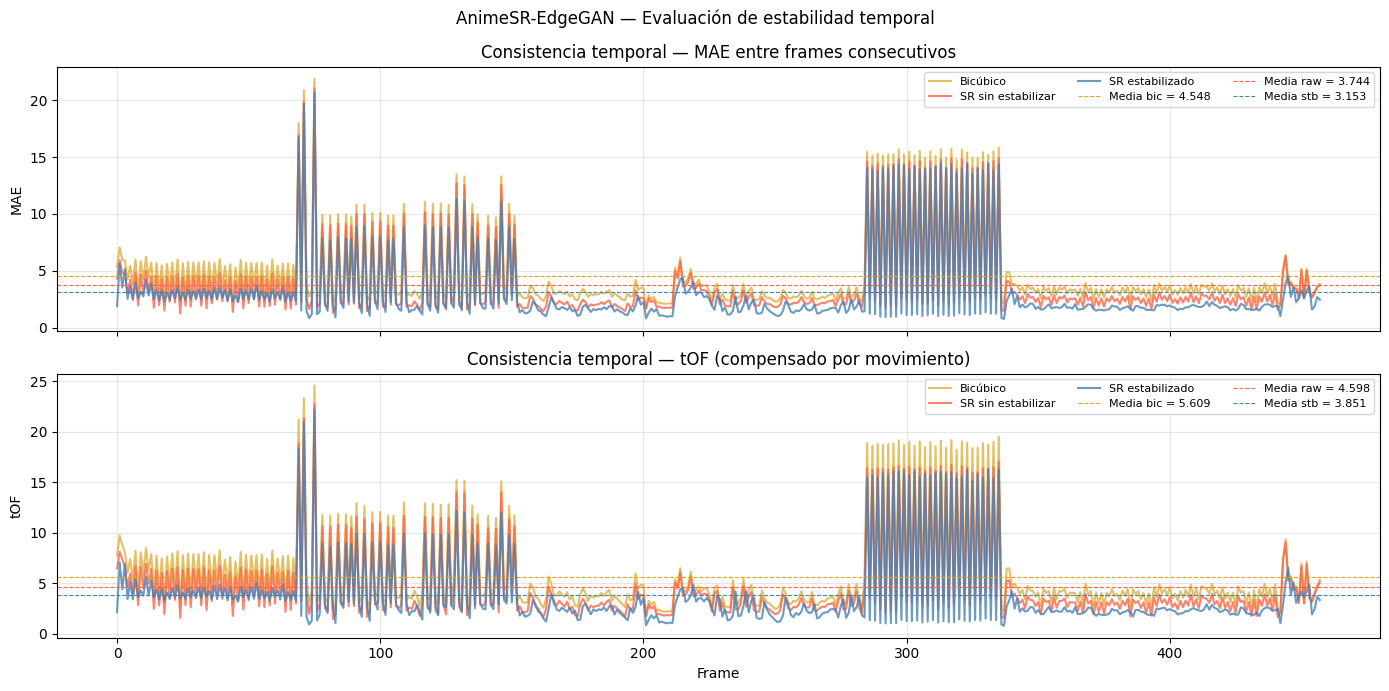

Gráfica guardada en: pruebas/output/temporal_metrics.png


In [27]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA — Inferencia de vídeo con estabilización temporal
#  Métricas: MAE y tOF sobre tres métodos:
#    - Bicúbico (baseline LR upscaleado)
#    - SR sin estabilización
#    - SR con estabilización temporal
# ══════════════════════════════════════════════════════════════════════
from infer_vid import TemporalStabilizer, upscale
from utils import calcular_error_temporal
import matplotlib.pyplot as plt

# ── Métrica tOF ──────────────────────────────────────────────────────
def calcular_tof(frame_actual: np.ndarray, frame_previo: np.ndarray) -> float:
    """
    Temporal Optical Flow warping error.
    Compensa el movimiento legítimo antes de medir la inconsistencia temporal.
    Referencia: EDVR, BasicVSR papers.
    A diferencia del MAE, no penaliza escenas con movimiento rápido.
    """
    prev_gray = cv2.cvtColor(frame_previo, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame_actual, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    H, W = flow.shape[:2]
    grid_x, grid_y = np.meshgrid(np.arange(W, dtype=np.float32),
                                  np.arange(H, dtype=np.float32))
    map_x = (grid_x + flow[..., 0]).astype(np.float32)
    map_y = (grid_y + flow[..., 1]).astype(np.float32)
    prev_warped = cv2.remap(frame_previo, map_x, map_y,
                            cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return float(np.mean(cv2.absdiff(frame_actual, prev_warped)))


# ── Parámetros ───────────────────────────────────────────────────────
TEMPORAL_CFG = dict(
    scale    = 4,
    strength = 0.55,
    occ_thr  = 7.0,
    cut_thr  = 22.0,
    winsize  = 21,
)

FRAMES_DIR = PATHS['clip_frames']
OUTPUT_DIR = PATHS['output_video']
CKPT       = 'generator_final.pth'

frames = sorted(glob.glob(os.path.join(FRAMES_DIR, '*.png')))
print(f"Frames encontrados: {len(frames)}")
print(f"Checkpoint:         {CKPT}")
print(f"Scale:              x{TEMPORAL_CFG['scale']}")

# ── Cargar modelo ────────────────────────────────────────────────────
state  = torch.load(CKPT, map_location=DEVICE)
G_test = AnimeEdgeGenerator(num_features=64, num_rrdb=8, growth=32).to(DEVICE)
G_test.load_state_dict(state)
G_test.eval()
G_test = G_test.half()
torch.backends.cudnn.benchmark = True

print("Calentando cuDNN...")
with torch.no_grad():
    _t  = to_tensor(cv2.imread(frames[0])).to(DEVICE).half()
    _x2 = G_test(_t)
    _   = G_test(_x2)
    del _t, _x2, _
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("Calentamiento completado\n")

# ── Inicializar estabilizador y acumuladores ─────────────────────────
stabilizer = TemporalStabilizer(**TEMPORAL_CFG)

bic_mae,    bic_tof    = [], []
raw_mae,    raw_tof    = [], []
stable_mae, stable_tof = [], []

prev_bic, prev_raw, prev_stable = None, None, None
cuts_detectados = 0

os.makedirs(OUTPUT_DIR, exist_ok=True)

h_lr, w_lr = cv2.imread(frames[0]).shape[:2]
H_sr, W_sr = h_lr * TEMPORAL_CFG['scale'], w_lr * TEMPORAL_CFG['scale']
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

vw_bic    = cv2.VideoWriter(f'{OUTPUT_DIR}/video_bicubic.mp4',
                             fourcc, 24.0, (W_sr, H_sr))
vw_raw    = cv2.VideoWriter(f'{OUTPUT_DIR}/video_raw.mp4',
                             fourcc, 24.0, (W_sr, H_sr))
vw_stable = cv2.VideoWriter(f'{OUTPUT_DIR}/video_stable.mp4',
                             fourcc, 24.0, (W_sr, H_sr))
vw_side   = cv2.VideoWriter(f'{OUTPUT_DIR}/video_sbs.mp4',
                             fourcc, 24.0, (W_sr * 3, H_sr))  # tres en fila

# ── Bucle principal ──────────────────────────────────────────────────
pbar = tqdm(frames, desc='Inferencia')
for frame_path in pbar:
    img_lr = cv2.imread(frame_path)

    # 1. Bicúbico (baseline)
    sr_bic = cv2.resize(img_lr, (W_sr, H_sr), interpolation=cv2.INTER_CUBIC)

    # 2. Super-resolución x4
    with torch.no_grad():
        sr_raw = to_image(upscale(G_test, to_tensor(img_lr).to(DEVICE).half(),
                                  scale=TEMPORAL_CFG['scale']))

    # 3. Estabilización temporal
    sr_stable = stabilizer(img_lr, sr_raw)

    if stabilizer._scene_cut_flag:
        cuts_detectados += 1

    # 4. Métricas (excluir frames de corte de escena)
    skip = stabilizer._scene_cut_flag
    if prev_bic    is not None and not skip:
        bic_mae.append(calcular_error_temporal(sr_bic,    prev_bic))
        bic_tof.append(calcular_tof(sr_bic,               prev_bic))
    if prev_raw    is not None and not skip:
        raw_mae.append(calcular_error_temporal(sr_raw,    prev_raw))
        raw_tof.append(calcular_tof(sr_raw,               prev_raw))
    if prev_stable is not None and not skip:
        stable_mae.append(calcular_error_temporal(sr_stable, prev_stable))
        stable_tof.append(calcular_tof(sr_stable,            prev_stable))

    prev_bic, prev_raw, prev_stable = sr_bic, sr_raw, sr_stable

    # 5. Escribir vídeos
    vw_bic.write(sr_bic)
    vw_raw.write(sr_raw)
    vw_stable.write(sr_stable)
    vw_side.write(np.concatenate([sr_bic, sr_raw, sr_stable], axis=1))

    pbar.set_postfix({
        'MAE_bic': f'{bic_mae[-1]:.3f}'    if bic_mae    else '-',
        'MAE_raw': f'{raw_mae[-1]:.3f}'    if raw_mae    else '-',
        'MAE_stb': f'{stable_mae[-1]:.3f}' if stable_mae else '-',
    })

vw_bic.release()
vw_raw.release()
vw_stable.release()
vw_side.release()

# ── Resumen numérico ─────────────────────────────────────────────────
def _m(lst): return np.mean(lst) if lst else 0.0

mean_bic_mae    = _m(bic_mae)
mean_raw_mae    = _m(raw_mae)
mean_stable_mae = _m(stable_mae)
mean_bic_tof    = _m(bic_tof)
mean_raw_tof    = _m(raw_tof)
mean_stable_tof = _m(stable_tof)

# Reducción respecto al bicúbico (baseline)
def _red(val, base): return (1.0 - val / base) * 100 if base > 0 else 0.0

print(f"\n{'─'*62}")
print(f"  {'Métrica':<28} {'Bicúbico':>8}  {'SR raw':>8}  {'SR estab.':>9}  {'Δ vs bic':>8}")
print(f"  {'─'*60}")
print(f"  {'MAE  (↓ mejor)':<28} {mean_bic_mae:>8.4f}  {mean_raw_mae:>8.4f}  "
      f"{mean_stable_mae:>9.4f}  {_red(mean_stable_mae, mean_bic_mae):>+7.1f}%")
print(f"  {'tOF  (↓ mejor)':<28} {mean_bic_tof:>8.4f}  {mean_raw_tof:>8.4f}  "
      f"{mean_stable_tof:>9.4f}  {_red(mean_stable_tof, mean_bic_tof):>+7.1f}%")
print(f"  {'─'*60}")
print(f"  Cortes de escena detectados: {cuts_detectados}")
print(f"  Frames evaluados:            {len(raw_mae)}")
print(f"{'─'*62}")
print(f"\n  video_bicubic.mp4 → baseline bicúbico")
print(f"  video_raw.mp4     → SR sin estabilización")
print(f"  video_stable.mp4  → SR con estabilización")
print(f"  video_sbs.mp4     → side-by-side (bicúbico | raw | estable)")

# ── Gráfica frame a frame ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, bic, raw, stb, mean_b, mean_r, mean_s, ylabel, title in [
    (axes[0], bic_mae, raw_mae, stable_mae,
     mean_bic_mae, mean_raw_mae, mean_stable_mae,
     'MAE', 'Consistencia temporal — MAE entre frames consecutivos'),
    (axes[1], bic_tof, raw_tof, stable_tof,
     mean_bic_tof, mean_raw_tof, mean_stable_tof,
     'tOF', 'Consistencia temporal — tOF (compensado por movimiento)'),
]:
    ax.plot(bic, label='Bicúbico',           color='goldenrod',  alpha=0.7)
    ax.plot(raw, label='SR sin estabilizar', color='tomato',     alpha=0.8)
    ax.plot(stb, label='SR estabilizado',    color='steelblue',  alpha=0.8)
    ax.axhline(mean_b, color='goldenrod',  linestyle='--', linewidth=0.8,
               label=f'Media bic = {mean_b:.3f}')
    ax.axhline(mean_r, color='tomato',     linestyle='--', linewidth=0.8,
               label=f'Media raw = {mean_r:.3f}')
    ax.axhline(mean_s, color='steelblue',  linestyle='--', linewidth=0.8,
               label=f'Media stb = {mean_s:.3f}')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=3)
    ax.grid(alpha=0.3)

axes[1].set_xlabel('Frame')
plt.suptitle('AnimeSR-EdgeGAN — Evaluación de estabilidad temporal', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/temporal_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfica guardada en: {OUTPUT_DIR}/temporal_metrics.png")

In [28]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA — Side-by-side: LR original (upscaleado) vs SR estabilizado
# ══════════════════════════════════════════════════════════════════════

FRAMES_DIR  = PATHS['clip_frames']
OUTPUT_DIR  = PATHS['output_video']
VIDEO_ESTAB = f'{OUTPUT_DIR}/video_stable.mp4'   # ya generado en la celda anterior
FPS         = 24.0

frames = sorted(glob.glob(os.path.join(FRAMES_DIR, '*.png')))
if not frames:
    raise FileNotFoundError(f"No se encontraron frames en {FRAMES_DIR}")

# Resolución del vídeo estabilizado
cap = cv2.VideoCapture(VIDEO_ESTAB)
if not cap.isOpened():
    raise FileNotFoundError(f"No se pudo abrir {VIDEO_ESTAB} — genera primero la celda de inferencia")

W_sr = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_sr = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_stable_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

if len(frames) != n_stable_frames:
    print(f"⚠ Aviso: frames LR ({len(frames)}) ≠ frames estabilizados ({n_stable_frames}). "
          f"Se usarán los primeros {min(len(frames), n_stable_frames)}.")

n_frames = min(len(frames), n_stable_frames)
fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
out_path = f'{OUTPUT_DIR}/video_original_vs_estabilizado.mp4'
vw       = cv2.VideoWriter(out_path, fourcc, FPS, (W_sr * 2, H_sr))

cap = cv2.VideoCapture(VIDEO_ESTAB)

pbar = tqdm(range(n_frames), desc='Generando comparativa')
for i in pbar:
    # Frame LR → bicúbico a resolución SR (el "original" escalado)
    img_lr = cv2.imread(frames[i])
    lr_up  = cv2.resize(img_lr, (W_sr, H_sr), interpolation=cv2.INTER_CUBIC)

    # Frame estabilizado del vídeo ya generado
    ret, sr_stable = cap.read()
    if not ret:
        break

    # Etiquetas sobreimpresas
    label_cfg = dict(fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1.2,
                     thickness=2, lineType=cv2.LINE_AA)
    offset = 10

    for text, img in [('Original (bicúbico)', lr_up), ('SR Estabilizado', sr_stable)]:
        # Sombra
        cv2.putText(img, text, (offset + 2, 38 + 2),
                    color=(0, 0, 0), **label_cfg)
        # Texto blanco
        cv2.putText(img, text, (offset, 38),
                    color=(255, 255, 255), **label_cfg)

    frame_sbs = np.concatenate([lr_up, sr_stable], axis=1)
    vw.write(frame_sbs)

cap.release()
vw.release()

print(f"Vídeo guardado en: {out_path}")
print(f"Resolución: {W_sr * 2}×{H_sr}  |  Frames: {n_frames}  |  FPS: {FPS}")

Generando comparativa:   0%|          | 0/465 [00:00<?, ?it/s]

Vídeo guardado en: pruebas/output/video_original_vs_estabilizado.mp4
Resolución: 5664×1920  |  Frames: 465  |  FPS: 24.0
